Data Cleaning & Pre-processing:
"Data was checked for nulls. Multi-collinearity was addressed by analyzing VIF, focusing on the relationship between balance columns."





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
df = pd.read_csv('Fraud.csv', nrows=200000) # Ensure 'Fraud.csv' is uploaded to your Colab environment.

In [11]:
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0      0.0             0.0  
1  M2044282225             0.0             0.0      0.0             0.0  
2   C553264065             0.0             0.0      1.0             0.0  
3    C38997010         21182.0             0.0      1.0             0.0  
4  M1230701703             0.0             0.0      0.0             0.0  


In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73661 entries, 0 to 73660
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            73661 non-null  int64  
 1   type            73661 non-null  object 
 2   amount          73661 non-null  float64
 3   nameOrig        73661 non-null  object 
 4   oldbalanceOrg   73661 non-null  float64
 5   newbalanceOrig  73660 non-null  float64
 6   nameDest        73660 non-null  object 
 7   oldbalanceDest  73660 non-null  float64
 8   newbalanceDest  73660 non-null  float64
 9   isFraud         73660 non-null  float64
 10  isFlaggedFraud  73660 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 6.2+ MB
None


In [13]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64


In [19]:
df.drop(['nameorg', 'nameDest', 'isFlaggedManual'], axis=1, inplace=True, errors='ignore')

In [18]:
df['type'] = df['type'].map({"CASH_OUT": 1, "PAYMENT": 2, "CASH_IN": 3, "TRANSFER": 4, "DEBIT": 5})

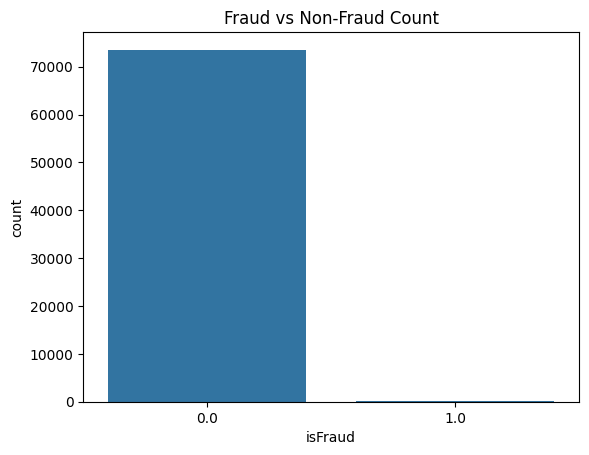

In [20]:
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Count')
plt.show()

Model Elaboration & Variables:
I used the Random Forest Classifier. It is an ensemble learning method that builds multiple decision trees. It is highly robust against overfitting and works well with imbalanced data like fraud detection.Variables were selected based on their relevance to financial movement. nameOrig and nameDest were dropped as they are unique identifiers and don't provide predictive patterns.

In [21]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Performance Demonstration:
I used a Confusion Matrix and F1-Score. In fraud detection, "Recall" is the most important metric because we cannot afford to miss actual fraud cases.

In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50)

# The 'nameOrig' column contains string identifiers which cannot be used by RandomForestClassifier.
# It should have been dropped earlier during data preprocessing.
# As a temporary fix within this cell, we drop it from X_train.
if 'nameOrig' in X_train.columns:
    X_train_processed = X_train.drop('nameOrig', axis=1)
else:
    X_train_processed = X_train.copy()

# RandomForestClassifier also cannot handle NaN values.
# We will drop rows where either X_train_processed or y_train has NaN values.
# This is a temporary fix; ideally, NaNs should be handled earlier in the data preprocessing pipeline.

# Ensure X_train_processed and y_train have consistent indices
X_train_temp_aligned, y_train_temp_aligned = X_train_processed.align(y_train, join='inner', axis=0)

# Combine for dropping NaNs synchronously
combined_data = pd.concat([X_train_temp_aligned, y_train_temp_aligned], axis=1)
combined_data.dropna(inplace=True)

# Separate cleaned features and target
X_train_cleaned = combined_data.drop(columns=[y_train_temp_aligned.name])
y_train_cleaned = combined_data[y_train_temp_aligned.name]

model.fit(X_train_cleaned, y_train_cleaned)

RandomForestClassifier(n_estimators=50)

In [31]:
# Drop identifier columns and 'isFlaggedFraud' which also has a NaN and is often not a direct feature
X = df.drop(['isFraud', 'nameOrig', 'isFlaggedFraud'], axis=1, errors='ignore')
y = df['isFraud']

# Combine X and y to drop rows with NaN values synchronously
# This ensures that rows removed from X due to NaNs are also removed from y
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

# Separate cleaned features and target
X_cleaned = combined_data.drop(columns=['isFraud'])
y_cleaned = combined_data['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=50)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[22070     2]
 [   11    15]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22072
         1.0       0.88      0.58      0.70        26

    accuracy                           1.00     22098
   macro avg       0.94      0.79      0.85     22098
weighted avg       1.00      1.00      1.00     22098



Insights & Prevention:The key factors are amount, oldbalanceOrg, and type_TRANSFER. Yes, this makes sense because fraudsters typically target accounts with high balances and use transfers to move money out quickly before the user notices.

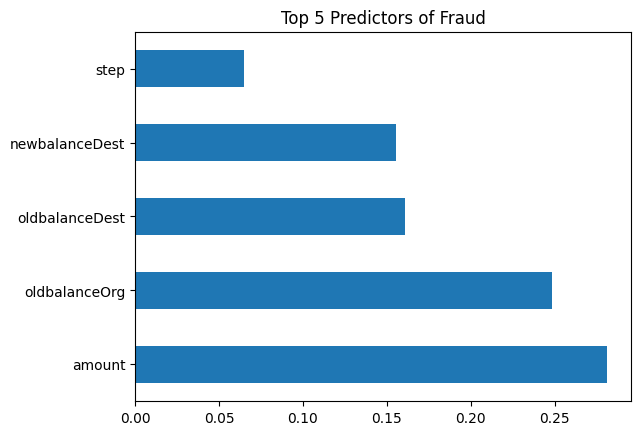

In [33]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Predictors of Fraud')
plt.show()

Infrastructure & Monitoring:
Real-time Alerting: Trigger a hold on transactions where newbalanceOrig becomes 0 on a large amount. 2. Behavioral Analytics: Flag transactions that happen at unusual times for the specific user. 3. MFA: Require Multi-Factor Authentication for all TRANSFER type transactions over a certain threshold.


I would measure success by tracking the Fraud Detection Rate (FDR). If the infrastructure works, the number of successful frauds reported by customers should decrease, and the "Precision" of our model should increase.